In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [3]:
attendance_data = pd.read_csv('monthly_attendance.csv')
attendance_data.head()

,Period,Type 1 Departments - Major A&E,Type 3 Departments - Other A&E/Minor Injury Unit
0,Aug-10,"1,138,652","559,358"
1,Sep-10,"1,150,728","550,359"
2,Oct-10,"1,163,143","583,244"
3,Nov-10,"1,111,295","486,005"
4,Dec-10,"1,159,204","533,001"


In [4]:
# Convert 'Period' to datetime format and clean numeric columns
attendance_data['Period'] = pd.to_datetime(attendance_data['Period'], format='%b-%y')
attendance_data.set_index('Period', inplace=True)
attendance_data['Type 1 Departments - Major A&E'] = attendance_data['Type 1 Departments - Major A&E'].str.replace(',', '')
attendance_data['Type 1 Departments - Major A&E'] = pd.to_numeric(attendance_data['Type 1 Departments - Major A&E'], errors='coerce')
attendance_data['Type 3 Departments - Other A&E/Minor Injury Unit'] = attendance_data['Type 3 Departments - Other A&E/Minor Injury Unit'].str.replace(',', '')
attendance_data['Type 3 Departments - Other A&E/Minor Injury Unit'] = pd.to_numeric(attendance_data['Type 3 Departments - Other A&E/Minor Injury Unit'], errors='coerce')
attendance_data.head()

,Type 1 Departments - Major A&E,Type 3 Departments - Other A&E/Minor Injury Unit
Period,,
2010-08-01,1138652,559358
2010-09-01,1150728,550359
2010-10-01,1163143,583244
2010-11-01,1111295,486005
2010-12-01,1159204,533001


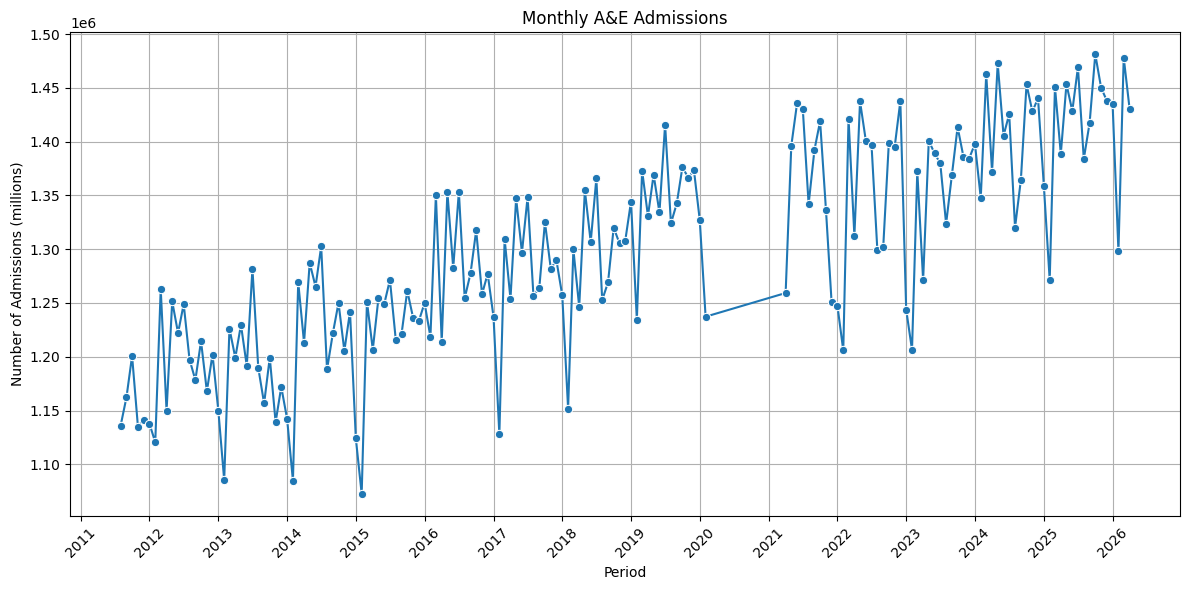

In [26]:
# plot the data
plt.figure(figsize=(12, 6))
sns.lineplot(x='Period', y='Type 1 Departments - Major A&E', data=attendance_data, marker='o')
# ---- The Fix: Set x-axis locator and formatter ----
ax = plt.gca() # Get the current axes
ax.xaxis.set_major_locator(mdates.YearLocator()) # Tick at every year
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Format the tick label as a 4-digit year (e.g., 2025)
plt.title('Monthly A&E Admissions')
plt.xlabel('Period')
plt.ylabel('Number of Admissions (millions)')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

## ARIMA

<Figure size 1000x500 with 0 Axes>

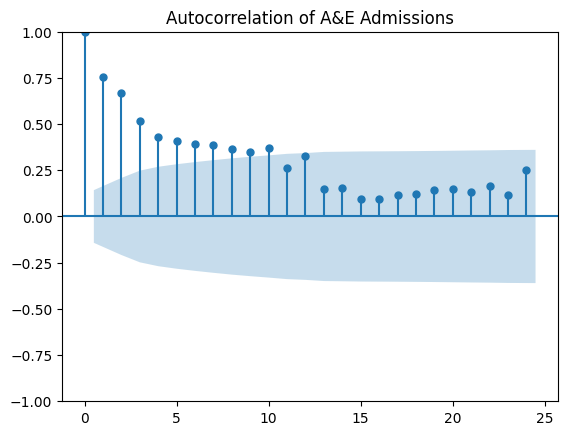

In [6]:
# compute and plot autocorrelation
from statsmodels.graphics.tsaplots import plot_acf
plt.figure(figsize=(10, 5))
plot_acf(attendance_data['Type 1 Departments - Major A&E'].dropna(), lags=24)
plt.title('Autocorrelation of A&E Admissions')
plt.show()

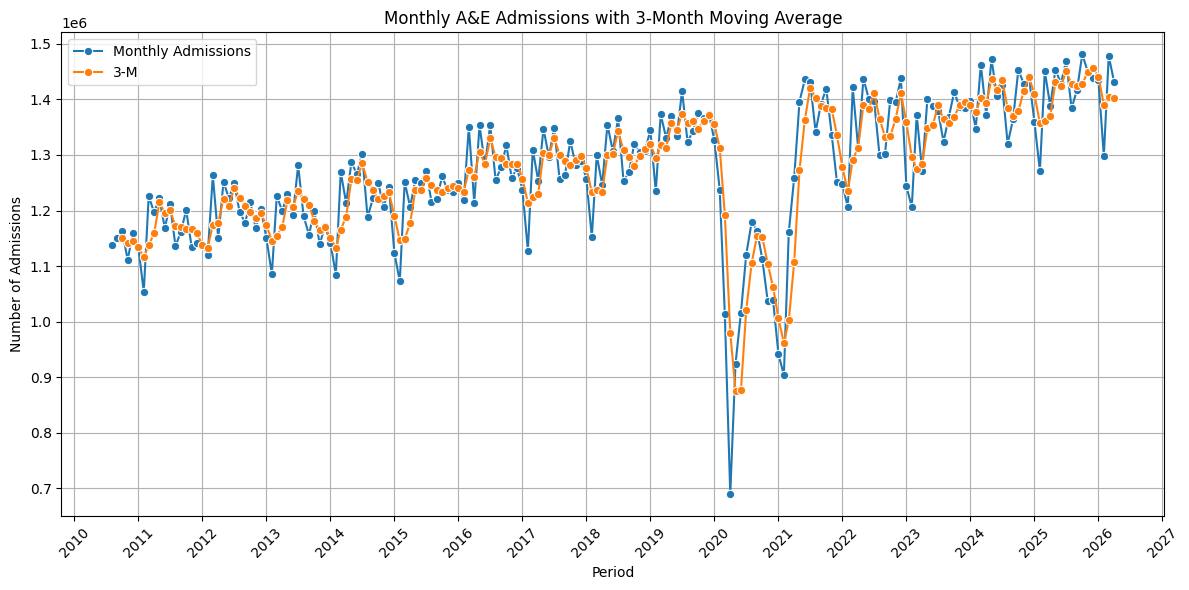

In [7]:
# compute and plot 3-month moving average
attendance_data['3-Month MA'] = attendance_data['Type 1 Departments - Major A&E'].rolling(window=3).mean()
plt.figure(figsize=(12, 6))
sns.lineplot(x='Period', y='Type 1 Departments - Major A&E', data=attendance_data, marker='o', label='Monthly Admissions')
sns.lineplot(x='Period', y='3-Month MA', data=attendance_data, marker='o', label='3-M')
# ---- The Fix: Set x-axis locator and formatter ----
ax = plt.gca() # Get the current axes
ax.xaxis.set_major_locator(mdates.YearLocator()) # Tick at every year
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Format the tick label as a 4-digit year (e.g., 2025)
plt.title('Monthly A&E Admissions with 3-Month Moving Average')
plt.xlabel('Period')
plt.ylabel('Number of Admissions')
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

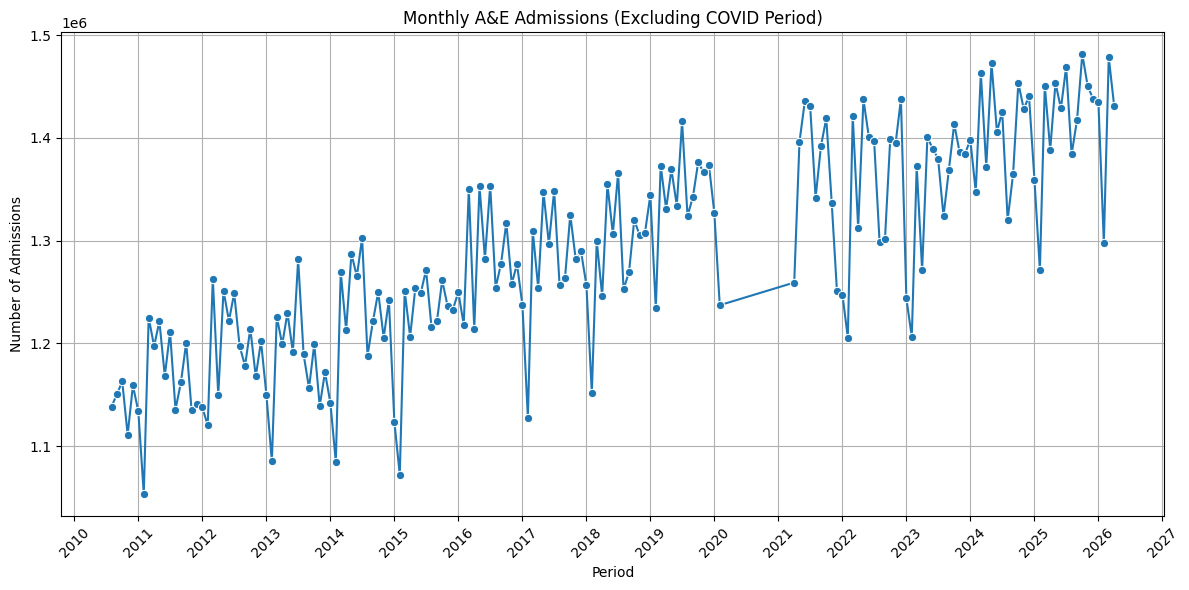

In [8]:
# ignore Covid period (Mar 2020 - Mar 2021) as this is an outlier that would skew our analysis and forecasting models. The pandemic caused unprecedented changes in healthcare utilization, including a significant drop in A&E admissions due to lockdowns and fear of infection. By excluding this period, we can focus on the underlying trends and seasonality in the data without the distortion caused by the pandemic, leading to more accurate and reliable forecasts for future admissions.
attendance_data_no_covid = attendance_data[~((attendance_data.index >= '2020-03-01') & (attendance_data.index <= '2021-03-31'))]
plt.figure(figsize=(12, 6))
sns.lineplot(x='Period', y='Type 1 Departments - Major A&E', data=attendance_data_no_covid, marker='o')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.title('Monthly A&E Admissions (Excluding COVID Period)')
plt.xlabel('Period')
plt.ylabel('Number of Admissions')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

In [9]:
# test data is last 12 months
train_data = attendance_data_no_covid[:-12]
test_data = attendance_data_no_covid[-12:]
print("Train data range:", train_data.index.min(), "to", train_data.index.max())
print("Test data range:", test_data.index.min(), "to", test_data.index.max())

Train data range: 2010-08-01 00:00:00 to 2025-04-01 00:00:00
Test data range: 2025-05-01 00:00:00 to 2026-04-01 00:00:00


In [10]:
# !pip install pmdarima (Run this if you don't have it installed)
from pmdarima import auto_arima

# Fit the SARIMA model
# Stepwise search is used to find the best combination of parameters (p, d, q) and seasonal parameters (P, D, Q) based on AIC. This approach is more efficient than a full grid search, especially for larger datasets or when there are many potential parameter combinations to evaluate.
model = auto_arima(
    train_data['Type 1 Departments - Major A&E'], 
    seasonal=True,   # Tell the model to look for seasonality
    m=12,            # Frequency of the seasonality (12 months)
    stepwise=True,   # Uses an efficient search algorithm rather than a massive grid search
    suppress_warnings=True,
    error_action="ignore"
)

print(model.summary())

# Forecast the next 12 months
forecast, conf_int = model.predict(n_periods=12, return_conf_int=True)

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  164
Model:             SARIMAX(0, 1, 1)x(2, 0, [], 12)   Log Likelihood               -2043.404
Date:                             Thu, 04 Jun 2026   AIC                           4094.808
Time:                                     08:21:50   BIC                           4107.183
Sample:                                          0   HQIC                          4099.832
                                             - 164                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.1777      0.021     -8.664      0.000      -0.218      -0.137
ar.S.L12       0.1505      

/Users/cex/Desktop/coding/A&E admissions/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/cex/Desktop/coding/A&E admissions/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


SARIMA model is typically represented as
$$SARIMA(p,d,q) \times (P,D,Q)_s$$

The first set of parentheses represents the non-seasonal (short-term) part of the model, and the second set represents the seasonal (long-term cyclic) part of the model. The subscript $s$ defines the seasonal period.
* $p$ (Autoregressive order): The number of consecutive past months the model looks back at to predict the current month.
* $d$ (Differencing order): The number of times the model subtracts consecutive months to remove a long-term trend and make the data stationary
* q (Moving Average order): The number of consecutive past forecast errors/shocks the model factors in.

Instead of blindly guessing or running a massive, slow grid search of every single possible combination, auto_arima uses a stepwise approach:
* Step A: Establishing the Baseline (Differencing). Before looking at AR or MA terms, the model has to figure out if the data is stationary.
* Step B: The Stepwise Search (Testing Combinations). It calculates the AIC (Akaike Information Criterion) for each one. The algorithm then systematically alters the parameters—incrementing or decrementing p, q, P, and Q by 1—to see if the AIC score drops.

In the result above the algorithm tried different configurations and copared AIC for each one. The best configuration it arrived at was $(0, 1, 1) \times (2, 0, 0)_{12}$.

Why d=1 and D=0?: The data has a clear upward baseline trend over the years, so it needed one round of regular differencing to flatten it out. However, because the winter spikes and summer troughs are relatively stable and proportional over year-over-year, the model found that adding a seasonal difference (D=1) would be "over-differencing" (adding unnecesssary noise), so it kept D=0.

Why p=0 and q=1?: The model found that trying to predict this month based on last month's exact value (p) didn't add any statistically significant predictive power once the trend was removed. However, factoring in the error/shock from last month (q=1, the Moving Average) helped smooth out short-term fluctuations brilliantly.

Why P=2 and Q=0?: Because it didn't use seasonal differencing, the model needed a way to remember the annual cycle. It discovered a very strong statistical relationship between the current month and the same month 12 months ago and 24 months ago. Adding a seasonal moving average (Q) on top of that didn't lower the AIC any further, so it left it blank ([]).

/Users/cex/Desktop/coding/A&E admissions/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/cex/Desktop/coding/A&E admissions/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


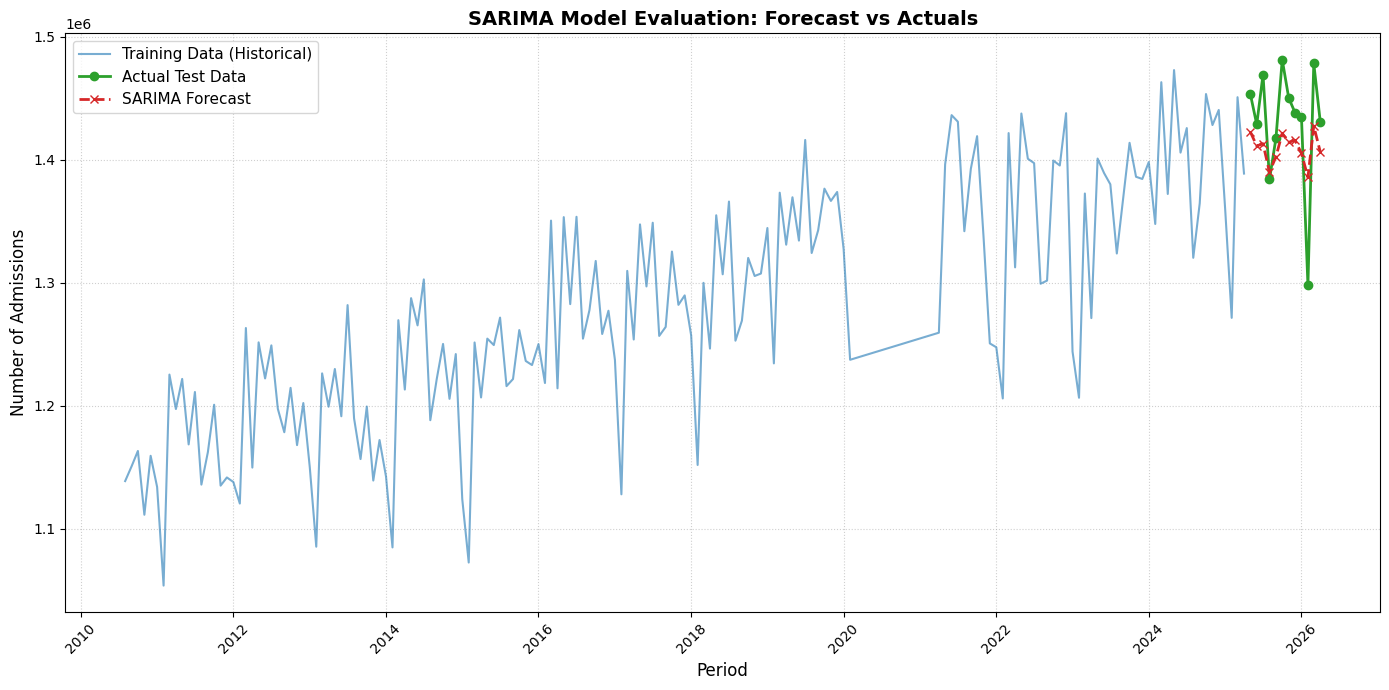

In [11]:
import matplotlib.pyplot as plt

# 1. Generate the forecast predictions
# (Make sure to pass the test set's exogenous data if your model requires it)
predictions = model.predict(n_periods=12)

# 2. Convert predictions into a Pandas Series with the correct test index 
# This ensures it lines up perfectly on the x-axis plot
forecast_series = pd.Series(predictions.values, index=test_data.index)

# 3. Plotting everything together
plt.figure(figsize=(14, 7))

# Plot the training data (optional: you can slice it to show only recent years for clarity)
plt.plot(train_data.index, train_data['Type 1 Departments - Major A&E'], 
         label='Training Data (Historical)', color='#1f77b4', alpha=0.6)

# Plot the actual historical test data (what actually happened)
plt.plot(test_data.index, test_data['Type 1 Departments - Major A&E'], 
         label='Actual Test Data', color='#2ca02c', marker='o', linewidth=2)

# Plot your SARIMA model's predictions
plt.plot(forecast_series.index, forecast_series, 
         label='SARIMA Forecast', color='#d62728', linestyle='--', marker='x', linewidth=2)

# Formatting the plot
plt.title('SARIMA Model Evaluation: Forecast vs Actuals', fontsize=14, fontweight='bold')
plt.xlabel('Period', fontsize=12)
plt.ylabel('Number of Admissions', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', fontsize=11)

# Rotate dates for readability
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

What we are observing is a classic trait of parsimonious statistical models like SARIMA. Because they rely heavily on historical averages and moving averages, they tend to play it safe. They are great at capturing the correct direction (the phase of the seasonality), but they often dampen the peaks and troughs, underestimating the true volatility or magnitude of those winter rushes.

In [12]:
# Compute Mean Absolute Error (MAE) and Mean Absolute Percentage Error (MAPE)
# We're using MAE because it gives us a clear average error in the same units as our data, which is easier to interpret for stakeholders. MAPE is also useful as it provides a percentage error, but it can be misleading if actual values are very low (since it can inflate the percentage error). In our case, since A&E admissions are generally not close to zero, MAPE can still provide valuable insight into the relative accuracy of our forecasts.
from sklearn.metrics import mean_absolute_error
import numpy as np
mae = mean_absolute_error(test_data['Type 1 Departments - Major A&E'], forecast_series)
mape = np.mean(np.abs((test_data['Type 1 Departments - Major A&E'] - forecast_series) / test_data['Type 1 Departments - Major A&E'])) * 100
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 36394.65
Mean Absolute Percentage Error (MAPE): 2.56%


What we are observing is a classic trait of parsimonious statistical models like SARIMA. Because they rely heavily on historical averages and moving averages, they tend to play it safe. They are great at capturing the correct direction (the phase of the seasonality), but they often dampen the peaks and troughs, underestimating the true volatility or magnitude of those winter rushes.

## Trees

Trees don't extrapolate trends, instead they're looking at a snapshot of features for prediction.
Decision trees cannot predict a value higher or lower than what they have seen in the training data.
Because the A&E attendance data has a steady upward baseline trend, the future values (in 2026 and beyond) will likely be higher than the historical values. Therefore, we need to detrend the data.

In [13]:
# feature engineering - add lag features
attendance_data = attendance_data_no_covid
attendance_data['month'] = attendance_data.index.month
attendance_data['lag_1'] = attendance_data['Type 1 Departments - Major A&E'].shift(1)
attendance_data['lag_12'] = attendance_data['Type 1 Departments - Major A&E'].shift(12)
attendance_data['rolling_mean_3'] = attendance_data['Type 1 Departments - Major A&E'].shift(1).rolling(3).mean()

In [14]:
attendance_data = attendance_data.dropna()
attendance_data.head()

,Type 1 Departments - Major A&E,Type 3 Departments - Other A&E/Minor Injury Unit,3-Month MA,month,lag_1,lag_12,rolling_mean_3
Period,,,,,,,
2011-08-01,1135801,570417,1.171778e+06,8,1211066.0,1138652.0,1.200407e+06
2011-09-01,1162143,566738,1.169670e+06,9,1135801.0,1150728.0,1.171778e+06
2011-10-01,1200708,593757,1.166217e+06,10,1162143.0,1163143.0,1.169670e+06
2011-11-01,1134959,554709,1.165937e+06,11,1200708.0,1111295.0,1.166217e+06
2011-12-01,1141606,542479,1.159091e+06,12,1134959.0,1159204.0,1.165937e+06


In [15]:
# Define your feature columns and your target variable
feature_cols = ['month', 'lag_1', 'lag_12', 'rolling_mean_3']
target_col = 'Type 1 Departments - Major A&E'

# Split into Training and Testing sets (Last 12 months for testing)
train_ml = attendance_data.iloc[:-12]
test_ml = attendance_data.iloc[-12:]

X_train, y_train = train_ml[feature_cols], train_ml[target_col]
X_test, y_test = test_ml[feature_cols], test_ml[target_col]

In [16]:
X_train.head()

,month,lag_1,lag_12,rolling_mean_3
Period,,,,
2011-08-01,8,1211066.0,1138652.0,1.200407e+06
2011-09-01,9,1135801.0,1150728.0,1.171778e+06
2011-10-01,10,1162143.0,1163143.0,1.169670e+06
2011-11-01,11,1200708.0,1111295.0,1.166217e+06
2011-12-01,12,1134959.0,1159204.0,1.165937e+06


In [17]:
# !pip install lightgbm
import lightgbm as lgb

# Initialize the LightGBM Regressor
lgb_model = lgb.LGBMRegressor(
    n_estimators=100,      # Number of trees to build
    learning_rate=0.05,    # Step size shrinkage to prevent overfitting
    max_depth=5,           # Limits how deep the trees can grow
    random_state=42,
    verbosity=-1           # Suppresses unnecessary alert logs
)

# Fit the model on your training features
lgb_model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [18]:
# Predict the test set
lgb_preds = lgb_model.predict(X_test)

# Convert to a pandas Series with dates for easy plotting
lgb_forecast_series = pd.Series(lgb_preds, index=X_test.index)

# Quick look at the performance
from sklearn.metrics import mean_absolute_error
lgb_mae = mean_absolute_error(y_test, lgb_preds)
print(f"LightGBM Test MAE: {lgb_mae:,.0f} admissions")

LightGBM Test MAE: 47,214 admissions


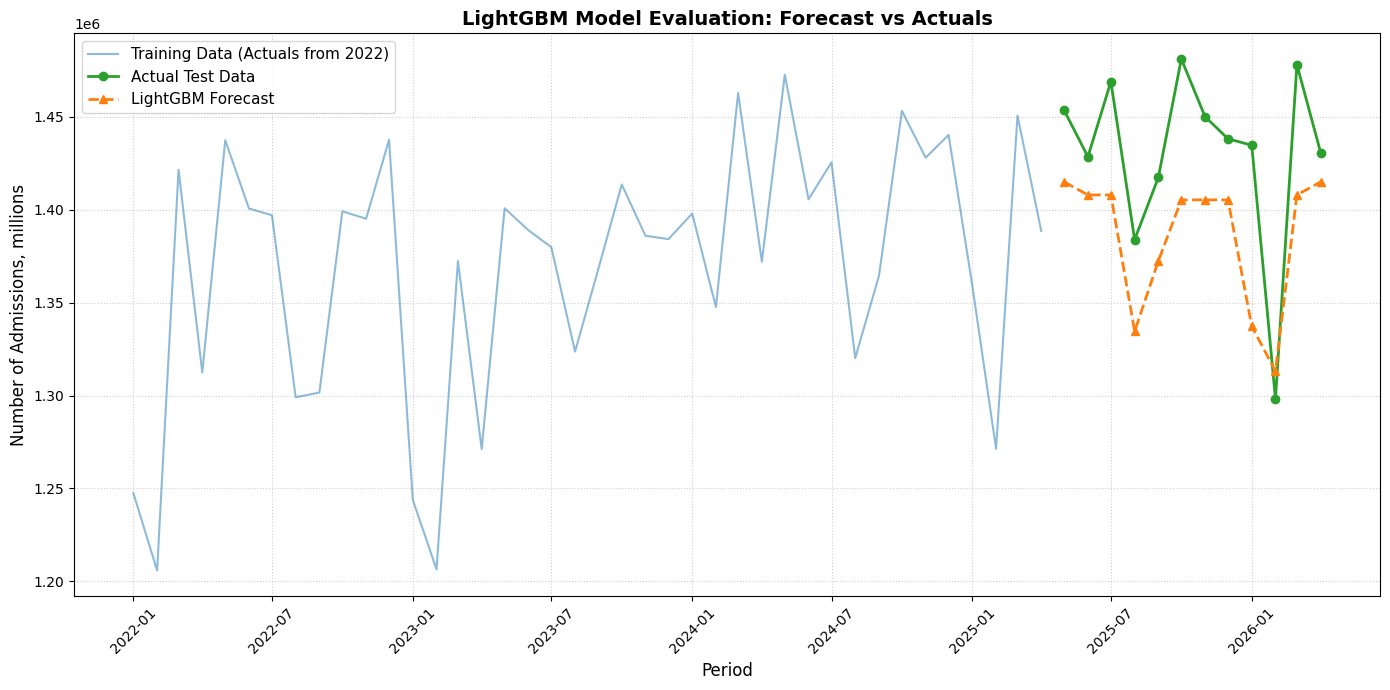

In [19]:
import matplotlib.pyplot as plt

# 1. Convert LightGBM predictions to a Pandas Series aligned with the test dates
lgb_forecast_series = pd.Series(lgb_preds, index=y_test.index)

# 2. Plotting the results
plt.figure(figsize=(14, 7))

# Plot recent historical training data for context (e.g., from 2022 onwards so it's not squished)
plt.plot(train_ml.loc['2022':].index, train_ml.loc['2022':, target_col], 
         label='Training Data (Actuals from 2022)', color='#1f77b4', alpha=0.5)

# Plot the true test data (the reality)
plt.plot(y_test.index, y_test, 
         label='Actual Test Data', color='#2ca02c', marker='o', linewidth=2)

# Plot the LightGBM forecast
plt.plot(lgb_forecast_series.index, lgb_forecast_series, 
         label='LightGBM Forecast', color='#ff7f0e', linestyle='--', marker='^', linewidth=2)

# Formatting the visualization
plt.title('LightGBM Model Evaluation: Forecast vs Actuals', fontsize=14, fontweight='bold')
plt.xlabel('Period', fontsize=12)
plt.ylabel('Number of Admissions, millions', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', fontsize=11)

# Clean up the x-axis date display
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The peaks and troughs are captured more accurately but the MAE is higher because the model consistently underpredicts the admissions. This is likely caused by the model's inability to capture the long-term raising trend of A&E admissions. One approach to remedy this is to model the trend with a linear regression and train lGBM on the residuals.

In [20]:
from sklearn.linear_model import LinearRegression

# --- STEP 1: Calculate the Linear Trend ---
# Create an integer time step (0, 1, 2...) representing time passing
attendance_data['time_step'] = np.arange(len(attendance_data))

# Split time steps into train and test windows
train_idx = attendance_data.index[:-12]
test_idx = attendance_data.index[-12:]

X_trend_train = attendance_data.loc[train_idx, ['time_step']]
y_trend_train = attendance_data.loc[train_idx, 'Type 1 Departments - Major A&E']
X_trend_test = attendance_data.loc[test_idx, ['time_step']]

# Fit Linear Regression on training data only to learn the macro trend
trend_model = LinearRegression()
trend_model.fit(X_trend_train, y_trend_train)

# Calculate the trend lines
attendance_data.loc[train_idx, 'linear_trend'] = trend_model.predict(X_trend_train)
attendance_data.loc[test_idx, 'linear_trend'] = trend_model.predict(X_trend_test)

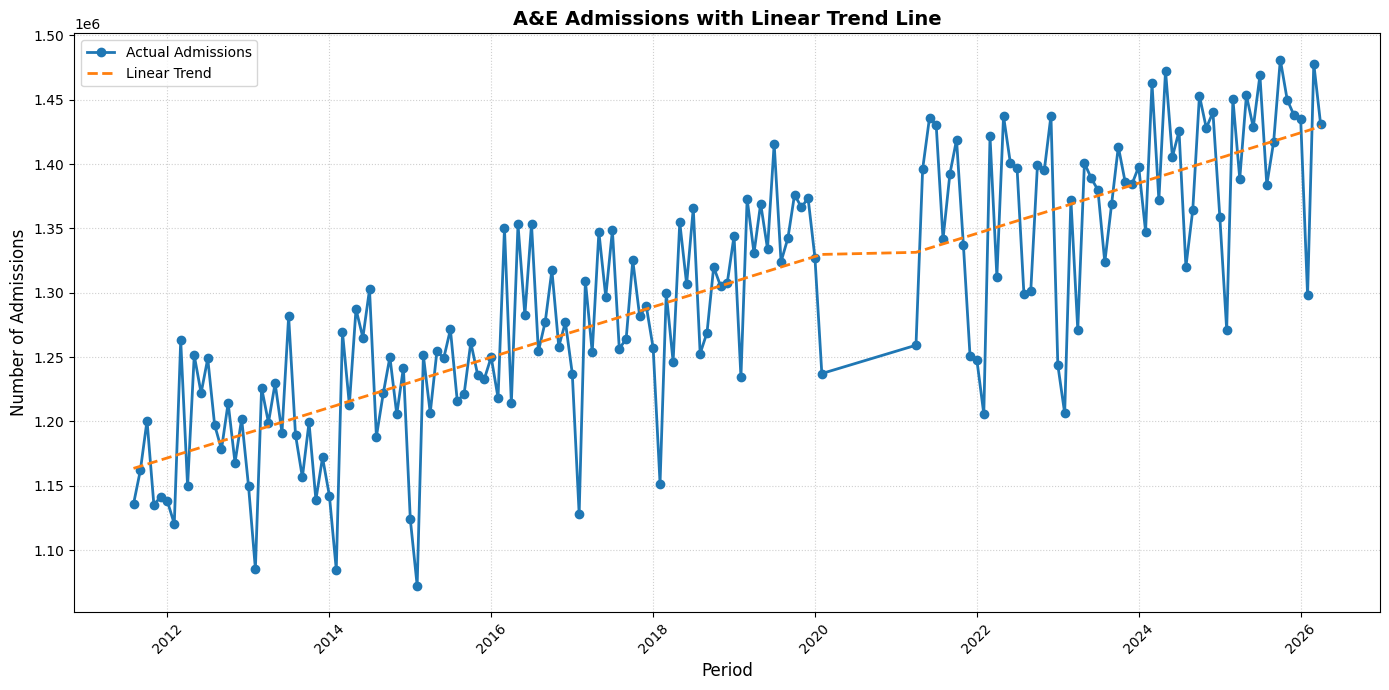

In [21]:
# plot the trend line along with actuals
plt.figure(figsize=(14, 7))
plt.plot(attendance_data.index, attendance_data['Type 1 Departments - Major A&E'], 
         label='Actual Admissions', color='#1f77b4', marker='o', linewidth=2)
plt.plot(attendance_data.index, attendance_data['linear_trend'], 
         label='Linear Trend', color='#ff7f0e', linestyle='--', linewidth=2)
plt.title('A&E Admissions with Linear Trend Line', fontsize=14, fontweight='bold')
plt.xlabel('Period', fontsize=12)
plt.ylabel('Number of Admissions', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)   
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
# --- STEP 2: Detrend the Target Variable ---
# Calculate 'residuals' (Actual value minus the trend line)
attendance_data['detrended_target'] = attendance_data['Type 1 Departments - Major A&E'] - attendance_data['linear_trend']

# --- STEP 3: Rebuild Features on the Detrended Data ---
attendance_data['month'] = attendance_data.index.month
attendance_data['detrended_lag_1'] = attendance_data['detrended_target'].shift(1)
attendance_data['detrended_lag_12'] = attendance_data['detrended_target'].shift(12)

# Drop rows with NaNs caused by the new shifts
df_clean = attendance_data.dropna()

# --- STEP 4: Train LightGBM on Flat Residuals ---
feature_cols = ['month', 'detrended_lag_1', 'detrended_lag_12']

X_train = df_clean.loc[df_clean.index.isin(train_idx), feature_cols]
y_train_residual = df_clean.loc[df_clean.index.isin(train_idx), 'detrended_target']

X_test = df_clean.loc[df_clean.index.isin(test_idx), feature_cols]
y_test_actual = df_clean.loc[df_clean.index.isin(test_idx), 'Type 1 Departments - Major A&E']

# Fit LightGBM
lgb_residual_model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, verbosity=-1)
lgb_residual_model.fit(X_train, y_train_residual)

# --- STEP 5: Recompose the Final Forecast ---
# Predict the flat wave component
residual_preds = lgb_residual_model.predict(X_test)

# Add the predicted flat wave back to the rising linear trend line
final_lgb_forecast = attendance_data.loc[test_idx, 'linear_trend'] + residual_preds

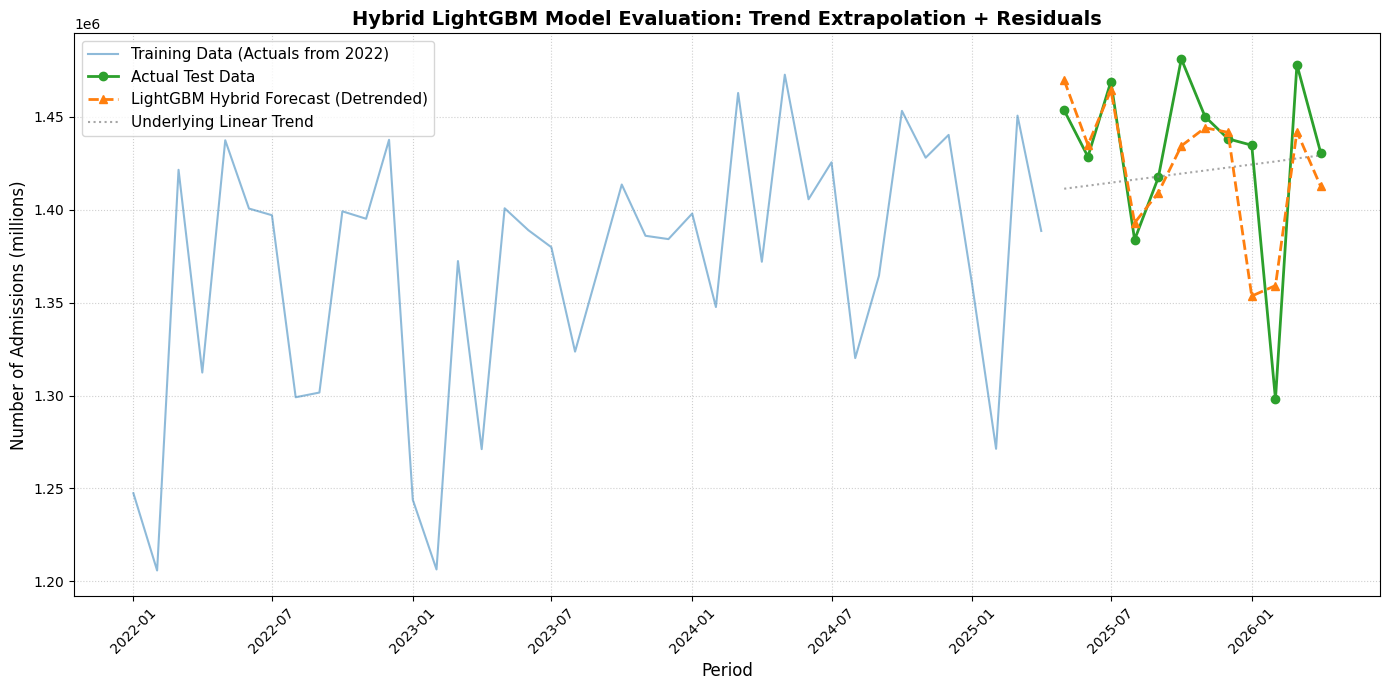

In [24]:
import matplotlib.pyplot as plt

# 1. Double check that final_lgb_forecast is a Pandas Series with the proper test index
# If it's a numpy array, we explicitly align it with the test dates:
if not isinstance(final_lgb_forecast, pd.Series):
    final_lgb_forecast = pd.Series(final_lgb_forecast, index=test_idx)

# 2. Plotting the hybrid results
plt.figure(figsize=(14, 7))

# Plot recent historical training data for background context (from 2022 onwards)
# Using df_ml since it contains the full historical target series
plt.plot(attendance_data.loc['2022':train_idx[-1]].index, 
         attendance_data.loc['2022':train_idx[-1], 'Type 1 Departments - Major A&E'], 
         label='Training Data (Actuals from 2022)', color='#1f77b4', alpha=0.5)

# Plot the true test data (what actually occurred)
plt.plot(test_idx, attendance_data.loc[test_idx, 'Type 1 Departments - Major A&E'], 
         label='Actual Test Data', color='#2ca02c', marker='o', linewidth=2)

# Plot the new Detrended LightGBM hybrid forecast
plt.plot(final_lgb_forecast.index, final_lgb_forecast, 
         label='LightGBM Hybrid Forecast (Detrended)', color='#ff7f0e', linestyle='--', marker='^', linewidth=2)

# Optional: Plot the underlying linear regression trend line to see the baseline path
plt.plot(final_lgb_forecast.index, attendance_data.loc[test_idx, 'linear_trend'], 
         label='Underlying Linear Trend', color='gray', linestyle=':', alpha=0.7)

# Formatting the visualization
plt.title('Hybrid LightGBM Model Evaluation: Trend Extrapolation + Residuals', fontsize=14, fontweight='bold')
plt.xlabel('Period', fontsize=12)
plt.ylabel('Number of Admissions (millions)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', fontsize=11)

# Clean up the x-axis date display
plt.xticks(rotation=45)
plt.tight_layout()

# Save the plot directly to your working directory
plt.savefig('lgb_hybrid_forecast.png', dpi=300)

In [25]:
# calculate MAE for the final hybrid forecast
hybrid_mae = mean_absolute_error(y_test_actual, final_lgb_forecast)
print(f"LightGBM Hybrid Forecast Test MAE: {hybrid_mae:,.0f} admissions")

LightGBM Hybrid Forecast Test MAE: 24,793 admissions


lightGBM with linear regression for detrending significantly outperformed SARIMA and captures the rising seasonal trend better.